In [2]:
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Flatten, Dense
import matplotlib.pyplot as plt
import numpy as np
from keras.models import load_model
from keras import regularizers
from keras.layers import Dropout
import pandas as pd
from keras.callbacks import EarlyStopping

# 1. Load Dataset

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(-1, 28,28,1)
X_test = X_test.reshape(-1, 28,28,1)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# 2. Define Model

In [4]:
model1 = Sequential()
model1.add(Flatten())
model1.add(Dense(64,activation='relu'))
model1.add(Dense(10,activation='softmax'))

# 3. Compile Model, Fit Model, Save Model, and Evaluate Model

In [5]:
model1.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['acc'])
history = model1.fit(X_train,y_train,epochs=10,batch_size=100,validation_data=(X_test,y_test))
history_baseline = history
model1.save('my_model1.h5')
model1.evaluate(X_test,y_test)

model1.summary()

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.8911 - loss: 0.3918 - val_acc: 0.9345 - val_loss: 0.2235
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9451 - loss: 0.1947 - val_acc: 0.9506 - val_loss: 0.1632
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9584 - loss: 0.1464 - val_acc: 0.9598 - val_loss: 0.1369
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9668 - loss: 0.1182 - val_acc: 0.9617 - val_loss: 0.1273
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.9713 - loss: 0.0994 - val_acc: 0.9687 - val_loss: 0.1093
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9758 - loss: 0.0847 - val_acc: 0.9708 - val_loss: 0.0992
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9782 - loss: 0.0738 - val_acc: 0.9713 - val_loss: 0.0990
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9810 - loss: 0.0645 - val_acc: 0.9729 - val_loss: 0.0919
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - ac

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - acc: 0.9722 - loss: 0.0927


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

# 4. Visualize Model Evaluation

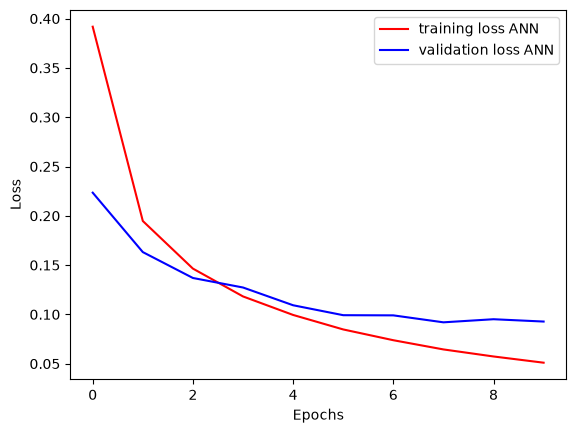

In [6]:
epochs = range(10)
loss1 = history.history['loss']
val_loss1 = history.history['val_loss']

plt.plot(epochs, loss1, 'r', label='training loss ANN')
plt.plot(epochs, val_loss1, 'b', label='validation loss ANN')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.savefig('baseline_loss.png')
plt.show()

# 5. Save Model

In [7]:
model_simpan = load_model('my_model1.h5')
pred = model_simpan.predict(X_test)
print('label actual:', np.argmax(y_test[30]))
print('label prediction:', np.argmax(pred[30]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
label actual: 3
label prediction: 3


## 2(a) L1 Regularization

In [8]:
# Setup Awal
alpha_rates = [0.01, 0.001, 0.0001]
history_l1 = {}
best_res = {}

# Menyimpan model terbaik
best_model = 0
best_rate = 0
best_acc = -1

# Looping rate
for rate in alpha_rates:
    print(f"Training L1 pada rate : {rate}")
    model_l1 = Sequential()
    model_l1.add(Flatten())
    model_l1.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l1(rate)))
    model_l1.add(Dense(10, activation='softmax'))
    
    model_l1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
    history = model_l1.fit(X_train, y_train, epochs=10, batch_size=100,
                            validation_data=(X_test, y_test))

    history_l1[rate] = history
    loss, acc = model_l1.evaluate(X_test, y_test, verbose=0)
    best_res[rate] = {
        'loss': loss,
        'acc': acc
    }
    
    print(f"Rate {rate} -> Loss: {loss:.4f}, Accuracy: {acc:.4f}")
    if acc > best_acc:
            best_acc = acc
            best_rate = rate
            best_model = model_l1

print(f"\nBest L1 Rate: {best_rate}")
print(f"Best Accuracy: {best_res[best_rate]['acc']:.4f}")
print(f"Best Loss: {best_res[best_rate]['loss']:.4f}")

Training L1 pada rate : 0.01
Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.7885 - loss: 2.6656 - val_acc: 0.8421 - val_loss: 1.2448
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.8440 - loss: 1.1497 - val_acc: 0.8562 - val_loss: 1.0495
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.8546 - loss: 1.0228 - val_acc: 0.8686 - val_loss: 0.9615
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.8601 - loss: 0.9594 - val_acc: 0.8689 - val_loss: 0.9177
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - acc: 0.8655 - loss: 0.9198 - val_acc: 0.8793 - val_loss: 0.8693
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.8691 - loss: 0.8881 - val_acc: 0.8759 - val_loss: 0.8487
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.8718 - loss: 0.8648 - val_acc: 0.8834 - val_loss: 0.8241
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.8750 - loss: 0.8425 - val_acc: 0.8792 - val_loss: 0.8249
Epoch 9/10
600/600 ━━━━━━━━

In [9]:
print("Summary Model L1:")
best_model.summary()

print("Evaluasi Model L1:")
best_model.evaluate(X_test, y_test)

Summary Model L1:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

Evaluasi Model L1:
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9715 - loss: 0.1775


[0.17752321064472198, 0.9714999794960022]

## Visualisasi L1 Regularization

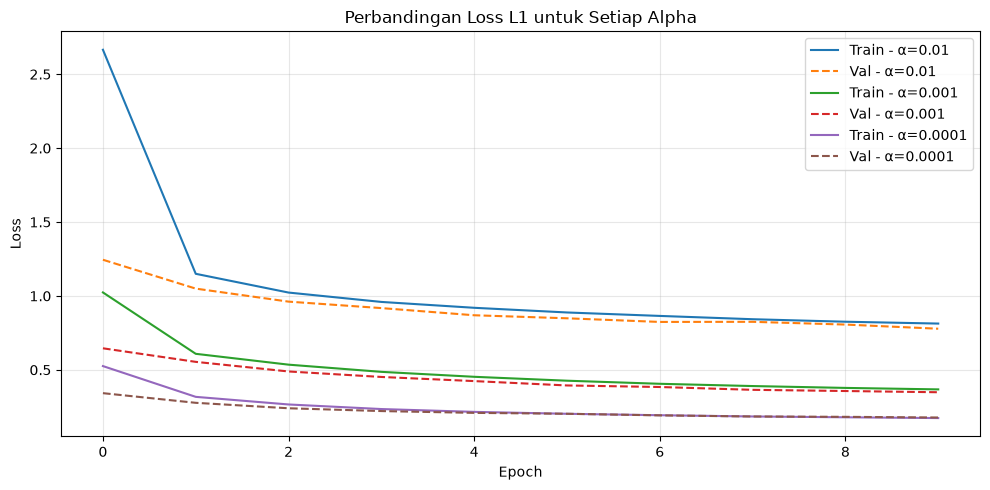

In [10]:
# Visualisasi Loss untuk setiap nilai Alpha L1
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(alpha_rates)):
    rate = alpha_rates[i]
    hist = history_l1[rate].history
    
    ax.plot(
        hist['loss'],
        label=f'Train - α={rate}'
    )
    ax.plot(
        hist['val_loss'],
        linestyle='--',
        label=f'Val - α={rate}'
    )
ax.set_title('Perbandingan Loss L1 untuk Setiap Alpha')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('l1_loss_comparison.png')
plt.show()
plt.close()

## Tabel hasil tiap alpha_rates

In [11]:
print(f"{'L1 Rate':<12}{'Test Loss':<15}{'Accuracy (%)':<15}")

for rate in alpha_rates:
    loss = best_res[rate]['loss']
    acc = best_res[rate]['acc'] * 100
    
    print(f"{rate:<12}{loss:<15.4f}{acc:<15.2f}")

print(f"Best L1 Rate : {best_rate}")
print(f"Best Accuracy: {best_acc * 100:.2f}%")

L1 Rate     Test Loss      Accuracy (%)   
0.01        0.7782         88.86          
0.001       0.3485         95.11          
0.0001      0.1775         97.15          
Best L1 Rate : 0.0001
Best Accuracy: 97.15%


# 2(b) L2 Regularization

In [12]:
# Setup Awal
l2_rates = [0.01, 0.001, 0.0001]
history_l2 = {}
best_res_l2 = {}

# Menyimpan model terbaik
best_model_l2 = None
best_rate_l2 = None
best_acc_l2 = -1

# Looping rate
for rate in l2_rates:
    print(f"Training L2 pada rate : {rate}")
    model_l2 = Sequential()
    model_l2.add(Flatten())
    model_l2.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l2(rate)))
    model_l2.add(Dense(10, activation='softmax'))
    
    model_l2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
    history = model_l2.fit(X_train, y_train, epochs=10, batch_size=100,
                            validation_data=(X_test, y_test))

    history_l2[rate] = history
    loss, acc = model_l2.evaluate(X_test, y_test, verbose=0)
    best_res_l2[rate] = {
        'loss': loss,
        'acc': acc
    }
    
    print(f"Rate {rate} -> Loss: {loss:.4f}, Accuracy: {acc:.4f}")
    if acc > best_acc_l2:
        best_acc_l2 = acc
        best_rate_l2 = rate
        best_model_l2 = model_l2

print(f"\nBest L2 Rate: {best_rate_l2}")
print(f"Best Accuracy: {best_res_l2[best_rate_l2]['acc']:.4f}")
print(f"Best Loss: {best_res_l2[best_rate_l2]['loss']:.4f}")


Training L2 pada rate : 0.01
Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.8793 - loss: 0.7352 - val_acc: 0.9173 - val_loss: 0.4544
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9171 - loss: 0.4358 - val_acc: 0.9285 - val_loss: 0.3924
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9292 - loss: 0.3859 - val_acc: 0.9317 - val_loss: 0.3681
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9355 - loss: 0.3528 - val_acc: 0.9444 - val_loss: 0.3250
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9401 - loss: 0.3312 - val_acc: 0.9410 - val_loss: 0.3138
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9440 - loss: 0.3114 - val_acc: 0.9435 - val_loss: 0.2983
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9462 - loss: 0.2983 - val_acc: 0.9493 - val_loss: 0.2846
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9496 - loss: 0.2840 - val_acc: 0.9534 - val_loss: 0.2669
Epoch 9/10
600/600 ━━━━━━━━

In [13]:
print("Summary Model L2:")
best_model_l2.summary()

print("Evaluasi Model L2:")
best_model_l2.evaluate(X_test, y_test)

Summary Model L2:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

Evaluasi Model L2:
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9737 - loss: 0.1110


[0.11102115362882614, 0.9736999869346619]

## Visualisasi L2 Regularization

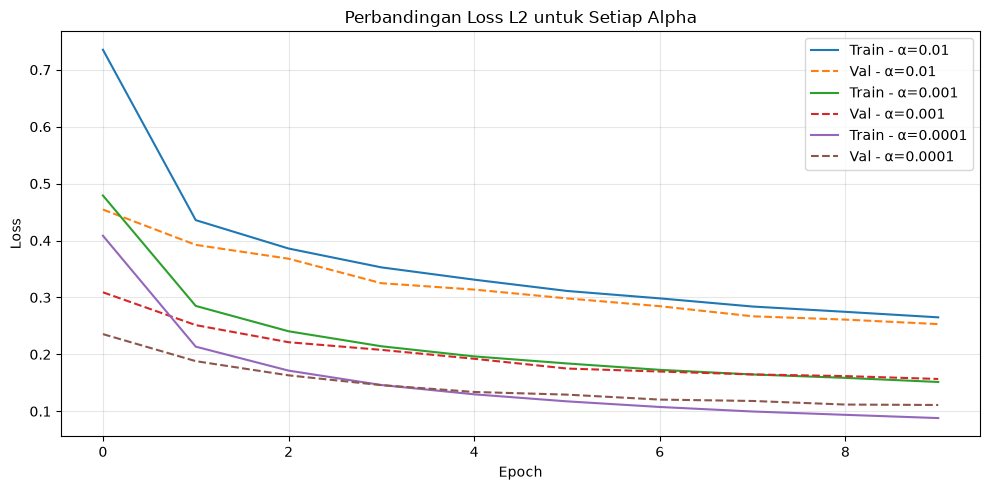

In [14]:
# Visualisasi Loss untuk setiap nilai Alpha L2
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(l2_rates)):
    rate = l2_rates[i]
    hist = history_l2[rate].history
    
    ax.plot(
        hist['loss'],
        label=f'Train - α={rate}'
    )
    ax.plot(
        hist['val_loss'],
        linestyle='--',
        label=f'Val - α={rate}'
    )
ax.set_title('Perbandingan Loss L2 untuk Setiap Alpha')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('l2_loss_comparison.png')
plt.show()
plt.close()


## Tabel hasil tiap L2_rates

In [15]:
print(f"{'L2 Rate':<12}{'Test Loss':<15}{'Accuracy (%)':<15}")

for rate in l2_rates:
    loss = best_res_l2[rate]['loss']
    acc = best_res_l2[rate]['acc'] * 100
    
    print(f"{rate:<12}{loss:<15.4f}{acc:<15.2f}")

print(f"Best L2 Rate : {best_rate_l2}")
print(f"Best Accuracy: {best_acc_l2 * 100:.2f}%")

L2 Rate     Test Loss      Accuracy (%)   
0.01        0.2531         95.67          
0.001       0.1567         97.07          
0.0001      0.1110         97.37          
Best L2 Rate : 0.0001
Best Accuracy: 97.37%


# 2(C) Dropout

In [16]:
# Setup Awal
dropout_rates = [0.2, 0.3, 0.4, 0.5]
history_do = {}
best_res_do = {}

# Menyimpan model terbaik
best_model_do = None
best_rate_do = None
best_acc_do = -1

# Looping rate
for rate in dropout_rates:
    print(f"Training Dropout pada rate : {rate}")
    model_do = Sequential()
    model_do.add(Flatten())
    model_do.add(Dense(64, activation='relu'))
    model_do.add(Dropout(rate))
    model_do.add(Dense(10, activation='softmax'))
    
    model_do.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
    history = model_do.fit(X_train, y_train, epochs=10, batch_size=100,
                           validation_data=(X_test, y_test))

    history_do[rate] = history
    loss, acc = model_do.evaluate(X_test, y_test, verbose=0)
    best_res_do[rate] = {
        'loss': loss,
        'acc': acc
    }
    
    print(f"Rate {rate} -> Loss: {loss:.4f}, Accuracy: {acc:.4f}")
    if acc > best_acc_do:
        best_acc_do = acc
        best_rate_do = rate
        best_model_do = model_do

print(f"\nBest Dropout Rate: {best_rate_do}")
print(f"Best Accuracy: {best_res_do[best_rate_do]['acc']:.4f}")
print(f"Best Loss: {best_res_do[best_rate_do]['loss']:.4f}")


Training Dropout pada rate : 0.2
Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.8713 - loss: 0.4493 - val_acc: 0.9367 - val_loss: 0.2195
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9307 - loss: 0.2380 - val_acc: 0.9537 - val_loss: 0.1637
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9442 - loss: 0.1896 - val_acc: 0.9586 - val_loss: 0.1394
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9516 - loss: 0.1626 - val_acc: 0.9632 - val_loss: 0.1241
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9568 - loss: 0.1444 - val_acc: 0.9680 - val_loss: 0.1109
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9609 - loss: 0.1323 - val_acc: 0.9705 - val_loss: 0.1018
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9640 - loss: 0.1188 - val_acc: 0.9711 - val_loss: 0.0989
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9668 - loss: 0.1109 - val_acc: 0.9705 - val_loss: 0.0963
Epoch 9/10
600/600 ━━━━

In [17]:
print("Summary Model Dropout:")
best_model_do.summary()

print("Evaluasi Model Dropout:")
best_model_do.evaluate(X_test, y_test)

Summary Model Dropout:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (100, 64)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

Evaluasi Model Dropout:
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9727 - loss: 0.0941


[0.09407917410135269, 0.9726999998092651]

## Visualisasi 2(C)

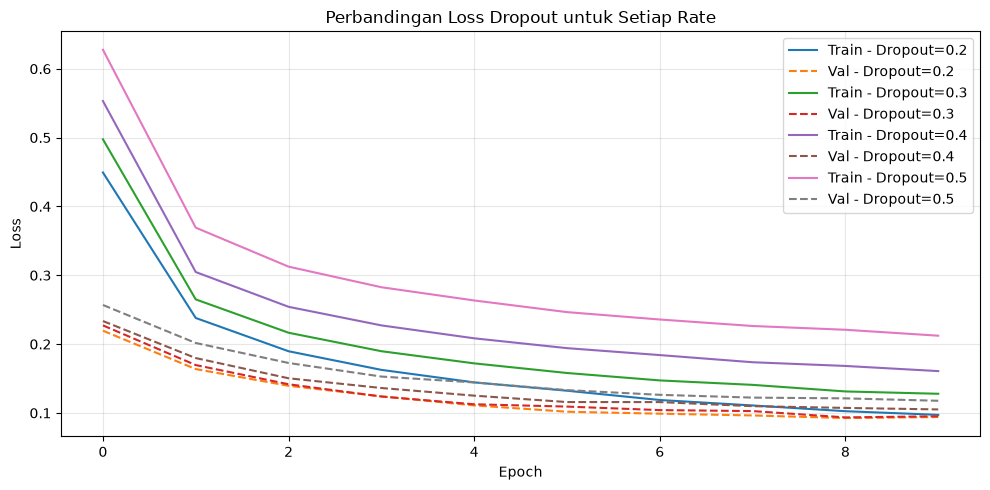

In [18]:
# Visualisasi Loss untuk setiap nilai Dropout
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(dropout_rates)):
    rate = dropout_rates[i]
    hist = history_do[rate].history
    
    ax.plot(
        hist['loss'],
        label=f'Train - Dropout={rate}'
    )
    ax.plot(
        hist['val_loss'],
        linestyle='--',
        label=f'Val - Dropout={rate}'
    )
ax.set_title('Perbandingan Loss Dropout untuk Setiap Rate')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dropout_loss_comparison.png')
plt.show()
plt.close()

## Tabel hasil tiap Dropout

In [19]:
print(f"{'Dropout Rate':<15}{'Test Loss':<15}{'Accuracy (%)':<15}")

for rate in dropout_rates:
    loss = best_res_do[rate]['loss']
    acc = best_res_do[rate]['acc'] * 100
    
    print(f"{rate:<15}{loss:<15.4f}{acc:<15.2f}")

print(f"Best Dropout Rate : {best_rate_do}")
print(f"Best Accuracy: {best_acc_do * 100:.2f}%")


Dropout Rate   Test Loss      Accuracy (%)   
0.2            0.0941         97.27          
0.3            0.0952         97.24          
0.4            0.1051         96.88          
0.5            0.1177         96.43          
Best Dropout Rate : 0.2
Best Accuracy: 97.27%


# 2(d) Early Stopping

In [20]:
# Setup Awal
patience_values = [1, 2, 3, 5]
history_es = {}
best_res_es = {}
stopped_epochs = {}

# Menyimpan model terbaik
best_model_es = None
best_patience = None
best_acc_es = -1

# Looping patience
for patience in patience_values:
    print(f"Training Early Stopping pada patience : {patience}")
    model_es = Sequential()
    model_es.add(Flatten())
    model_es.add(Dense(64, activation='relu'))
    model_es.add(Dense(10, activation='softmax'))
    
    model_es.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
    es_callback = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
    history = model_es.fit(X_train, y_train, epochs=20, batch_size=100,
                           validation_data=(X_test, y_test), callbacks=[es_callback])

    history_es[patience] = history
    stopped_epochs[patience] = len(history.history['loss'])
    loss, acc = model_es.evaluate(X_test, y_test, verbose=0)
    best_res_es[patience] = {
        'loss': loss,
        'acc': acc
    }
    
    print(f"Patience {patience} -> Berhenti di Epoch: {stopped_epochs[patience]}, Loss: {loss:.4f}, Accuracy: {acc:.4f}")
    if acc > best_acc_es:
        best_acc_es = acc
        best_patience = patience
        best_model_es = model_es

print(f"\nBest Patience: {best_patience}")
print(f"Best Accuracy: {best_res_es[best_patience]['acc']:.4f}")
print(f"Best Loss: {best_res_es[best_patience]['loss']:.4f}")


Training Early Stopping pada patience : 1
Epoch 1/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.8937 - loss: 0.3892 - val_acc: 0.9397 - val_loss: 0.2105
Epoch 2/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9469 - loss: 0.1884 - val_acc: 0.9543 - val_loss: 0.1585
Epoch 3/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9600 - loss: 0.1391 - val_acc: 0.9614 - val_loss: 0.1313
Epoch 4/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9679 - loss: 0.1123 - val_acc: 0.9662 - val_loss: 0.1152
Epoch 5/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9728 - loss: 0.0945 - val_acc: 0.9670 - val_loss: 0.1058
Epoch 6/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9768 - loss: 0.0809 - val_acc: 0.9693 - val_loss: 0.1022
Epoch 7/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9793 - loss: 0.0707 - val_acc: 0.9705 - val_loss: 0.0943
Epoch 8/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9818 - loss: 0.0619 - val_acc: 0.9730 - val_loss: 0.0861
Epoch 9/20
600

In [21]:
print("Summary Model Early Stopping:")
best_model_es.summary()

print("Evaluasi Model Early Stopping:")
best_model_es.evaluate(X_test, y_test)

Summary Model Early Stopping:


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_14 (Flatten)            │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

Evaluasi Model Early Stopping:
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9759 - loss: 0.0818


[0.0817885771393776, 0.9758999943733215]

## Visualisasi Early Stopping

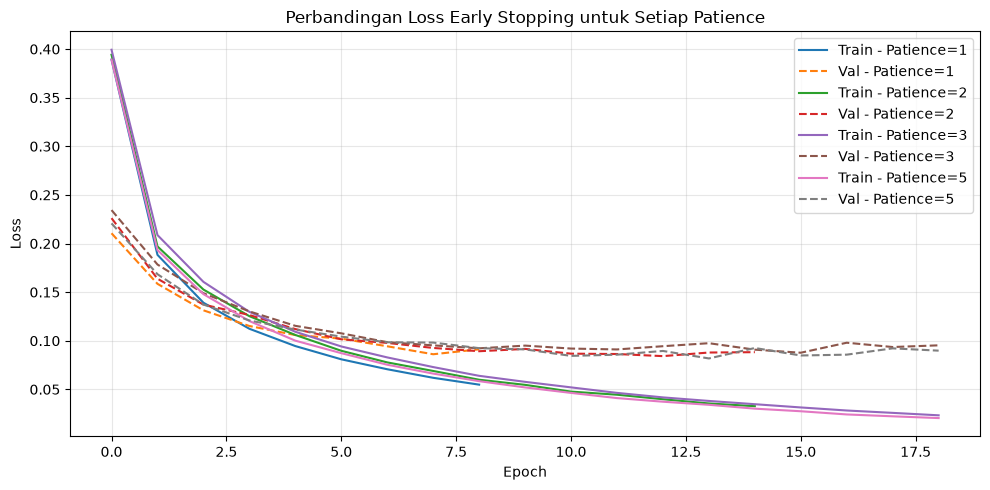

In [22]:
# Visualisasi Loss untuk setiap nilai Patience
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(patience_values)):
    patience = patience_values[i]
    hist = history_es[patience].history
    
    ax.plot(
        hist['loss'],
        label=f'Train - Patience={patience}'
    )
    ax.plot(
        hist['val_loss'],
        linestyle='--',
        label=f'Val - Patience={patience}'
    )
ax.set_title('Perbandingan Loss Early Stopping untuk Setiap Patience')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('earlystopping_loss_comparison.png')
plt.show()
plt.close()


## Tabel hasil ES

In [23]:
print(f"{'Patience':<12}{'Stop Epoch':<15}{'Test Loss':<15}{'Accuracy (%)':<15}")

for patience in patience_values:
    loss = best_res_es[patience]['loss']
    acc = best_res_es[patience]['acc'] * 100
    
    print(f"{patience:<12}{stopped_epochs[patience]:<15}{loss:<15.4f}{acc:<15.2f}")

print(f"Best Patience : {best_patience}")
print(f"Best Accuracy: {best_acc_es * 100:.2f}%")


Patience    Stop Epoch     Test Loss      Accuracy (%)   
1           9              0.0861         97.30          
2           15             0.0842         97.42          
3           19             0.0877         97.53          
5           19             0.0818         97.59          
Best Patience : 5
Best Accuracy: 97.59%


# 2(e) L1 Regularization dan Dropout

In [24]:
# Setup Awal
selected_l1 = best_rate
selected_dropout = best_rate_do

# Menyimpan model terbaik
model_comb = Sequential()
model_comb.add(Flatten())
model_comb.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l1(selected_l1)))
model_comb.add(Dropout(selected_dropout))
model_comb.add(Dense(10, activation='softmax'))

model_comb.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
history_comb = model_comb.fit(X_train, y_train, epochs=10, batch_size=100,
                              validation_data=(X_test, y_test))

loss_comb, acc_comb = model_comb.evaluate(X_test, y_test, verbose=0)

print(f"Konfigurasi L1: {selected_l1}")
print(f"Konfigurasi Dropout: {selected_dropout}")
print(f"Test Loss: {loss_comb:.4f}")
print(f"Test Accuracy: {acc_comb:.4f}")


Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - acc: 0.8684 - loss: 0.5963 - val_acc: 0.9322 - val_loss: 0.3556
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9256 - loss: 0.3740 - val_acc: 0.9489 - val_loss: 0.2918
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - acc: 0.9398 - loss: 0.3203 - val_acc: 0.9564 - val_loss: 0.2588
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9463 - loss: 0.2899 - val_acc: 0.9605 - val_loss: 0.2367
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9508 - loss: 0.2707 - val_acc: 0.9644 - val_loss: 0.2233
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - acc: 0.9534 - loss: 0.2566 - val_acc: 0.9652 - val_loss: 0.2157
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - acc: 0.9561 - loss: 0.2462 - val_acc: 0.9676 - val_loss: 0.2072
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - acc: 0.9575 - loss: 0.2385 - val_acc: 0.9689 - val_loss: 0.1987
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - ac

In [25]:
print("Summary Model L1 + Dropout:")
model_comb.summary()

print("Evaluasi Model L1 + Dropout:")
model_comb.evaluate(X_test, y_test)

Summary Model L1 + Dropout:


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_15 (Flatten)            │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (100, 64)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

Evaluasi Model L1 + Dropout:
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9699 - loss: 0.1961


[0.1961383819580078, 0.9699000120162964]

## Visualisasi L1 + Dropout

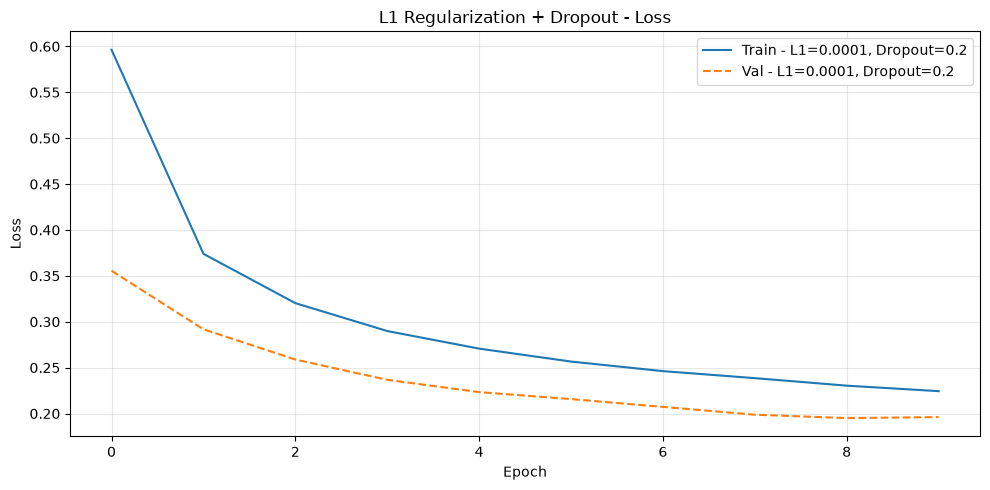

In [26]:
# Visualisasi Loss L1 + Dropout
fig, ax = plt.subplots(figsize=(10, 5))
hist = history_comb.history

ax.plot(
    hist['loss'],
    label=f'Train - L1={selected_l1}, Dropout={selected_dropout}'
)
ax.plot(
    hist['val_loss'],
    linestyle='--',
    label=f'Val - L1={selected_l1}, Dropout={selected_dropout}'
)
ax.set_title('L1 Regularization + Dropout - Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('l1_dropout_loss_comparison.png')
plt.show()
plt.close()


## Tabel hasil L1 + Dropout

In [27]:
print(f"{'L1 Rate':<12}{'Dropout Rate':<15}{'Test Loss':<15}{'Accuracy (%)':<15}")
print(f"{selected_l1:<12}{selected_dropout:<15}{loss_comb:<15.4f}{acc_comb * 100:<15.2f}")

L1 Rate     Dropout Rate   Test Loss      Accuracy (%)   
0.0001      0.2            0.1961         96.99          


# Perbandingan Seluruh Eksperimen

In [28]:
# Tabel perbandingan menggunakan Python biasa
comparison = [
    ('Baseline', history_baseline, model1, 'Tanpa Regularisasi'),
    ('L1', history_l1[best_rate], best_model, f'L1 = {best_rate}'),
    ('L2', history_l2[best_rate_l2], best_model_l2, f'L2 = {best_rate_l2}'),
    ('Dropout', history_do[best_rate_do], best_model_do, f'Dropout = {best_rate_do}'),
    ('Early Stopping', history_es[best_patience], best_model_es, f'Patience = {best_patience}'),
    ('L1 + Dropout', history_comb, model_comb, f'L1 = {selected_l1}, Dropout = {selected_dropout}'),
]

print(f"{'Skenario':<20}{'Konfigurasi':<32}{'Test Loss':<12}{'Test Acc (%)':<14}")
print('-' * 100)

for name, hist, model, config in comparison:
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    train_acc = hist.history['acc'][-1] * 100
    val_acc = hist.history['val_acc'][-1] * 100
    print(f"{name:<20}{config:<32}{loss:<12.4f}{acc * 100:<14.2f}")


Skenario            Konfigurasi                     Test Loss   Test Acc (%)  
----------------------------------------------------------------------------------------------------
Baseline            Tanpa Regularisasi              0.0927      97.22         
L1                  L1 = 0.0001                     0.1775      97.15         
L2                  L2 = 0.0001                     0.1110      97.37         
Dropout             Dropout = 0.2                   0.0941      97.27         
Early Stopping      Patience = 5                    0.0818      97.59         
L1 + Dropout        L1 = 0.0001, Dropout = 0.2      0.1961      96.99         
